In [1]:
!pip install -q qiskit qiskit-ae

ERROR: Could not find a version that satisfies the requirement qiskit-ae (from versions: none)
ERROR: No matching distribution found for qiskit-ae


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit_aer import AerSimulator


  Quantum Teleportation — Qiskit Aer Simulation

  Alice's encoding angle     : theta = pi/3 = 1.04720 rad
  Alice's mystery state      : Rx(1.0472)|0>
  Statevector                : [0.86603+0.j  0.     -0.5j]

  Expected P(|0>) after teleportation: 0.7500  (75.0%)
  Expected P(|1>) after teleportation: 0.2500  (25.0%)


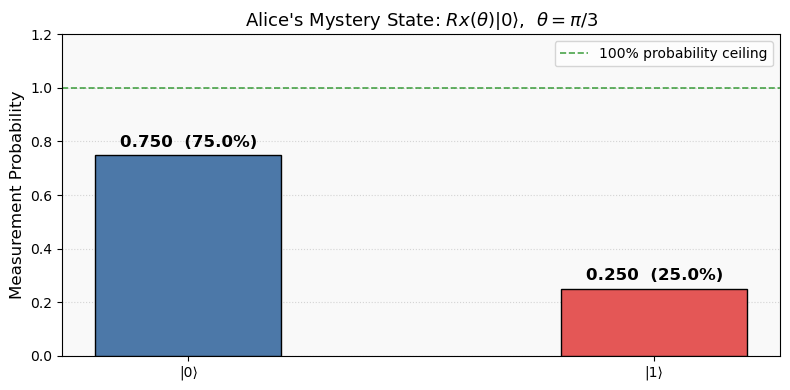


  ↑ This is the target state Bob must end up in after teleportation.


In [3]:
# ============================================================
# Quantum Teleportation Protocol — Pre-flight state analysis
# ============================================================
#
# Alice wants to teleport an arbitrary, unknown qubit state to Bob.
# We encode it as  Rx(theta)|0> = cos(theta/2)|0> - i*sin(theta/2)|1>
#
# Quantum teleportation requires:
#   - A shared Bell pair (EPR pair) between Alice and Bob
#   - 2 classical bits transmitted from Alice to Bob
#   - 0 quantum bits transmitted after setup
#
# It does NOT clone the quantum state. Alice's original qubit is
# destroyed by her Bell measurement (no-cloning theorem is obeyed).

THETA = np.pi / 3          # Encoding angle: identifiable, non-trivial state
SHOTS = 4096               # Shots for simulation

# Expected probabilities after teleportation (in Z basis)
P_ZERO = np.cos(THETA / 2) ** 2    # P(|0>) = cos^2(theta/2)
P_ONE  = np.sin(THETA / 2) ** 2    # P(|1>) = sin^2(theta/2)

# ── Analytical statevector of Alice's mystery qubit ──────────────
ref_qc = QuantumCircuit(1)
ref_qc.rx(THETA, 0)
alice_sv = Statevector(ref_qc)

print("=" * 62)
print("  Quantum Teleportation — Qiskit Aer Simulation")
print("=" * 62)
print(f"\n  Alice's encoding angle     : theta = pi/{int(np.pi/THETA):.0f} = {THETA:.5f} rad")
print(f"  Alice's mystery state      : Rx({THETA:.4f})|0>")
print(f"  Statevector                : {np.round(alice_sv.data, 5)}")
print(f"\n  Expected P(|0>) after teleportation: {P_ZERO:.4f}  ({100*P_ZERO:.1f}%)")
print(f"  Expected P(|1>) after teleportation: {P_ONE:.4f}  ({100*P_ONE:.1f}%)")

# ── Plot Alice's initial Bloch sphere angle ───────────────────────
fig_bloch, ax_b = plt.subplots(figsize=(8, 4))
ax_b.set_facecolor("#f9f9f9")
ax_b.set_title(
    rf"Alice's Mystery State: $Rx(\theta)|0\rangle$,  $\theta = \pi/3$",
    fontsize=13
)

labels = ["|0⟩", "|1⟩"]
probs  = [P_ZERO, P_ONE]
colors = ["#4c78a8", "#e45756"]

bars = ax_b.bar(labels, probs, color=colors, edgecolor="black",
                width=0.4, zorder=3)

for bar, p in zip(bars, probs):
    ax_b.text(bar.get_x() + bar.get_width() / 2, p + 0.02,
              f"{p:.3f}  ({100*p:.1f}%)",
              ha="center", va="bottom", fontsize=12, fontweight="bold")

ax_b.set_ylim(0, 1.2)
ax_b.set_ylabel("Measurement Probability", fontsize=12)
ax_b.axhline(1.0, color="green", linestyle="--", linewidth=1.2,
             label="100% probability ceiling", alpha=0.7)
ax_b.yaxis.grid(True, linestyle=":", alpha=0.5)
ax_b.set_axisbelow(True)
ax_b.legend(fontsize=10)

plt.tight_layout()
plt.show()
print("\n  ↑ This is the target state Bob must end up in after teleportation.")


Circuit construction complete.
Depth       : 9
Operations  : {'barrier': 5, 'measure': 3, 'h': 2, 'cx': 2, 'if_else': 2, 'rx': 1}

Text circuit view:



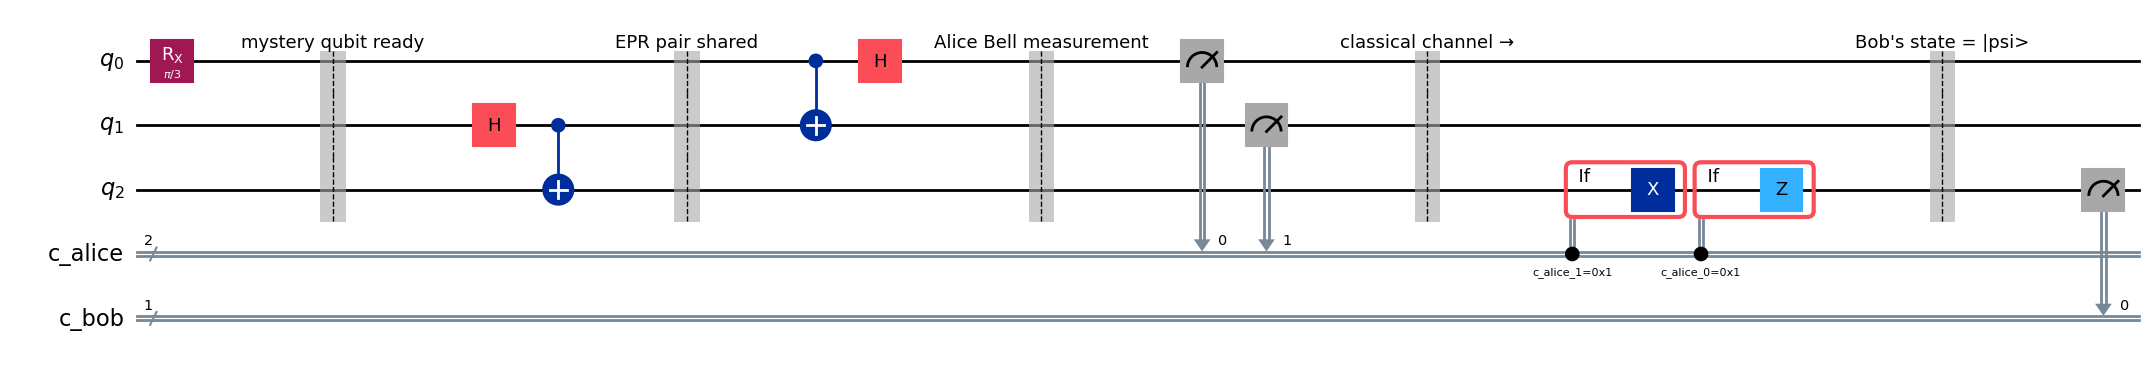

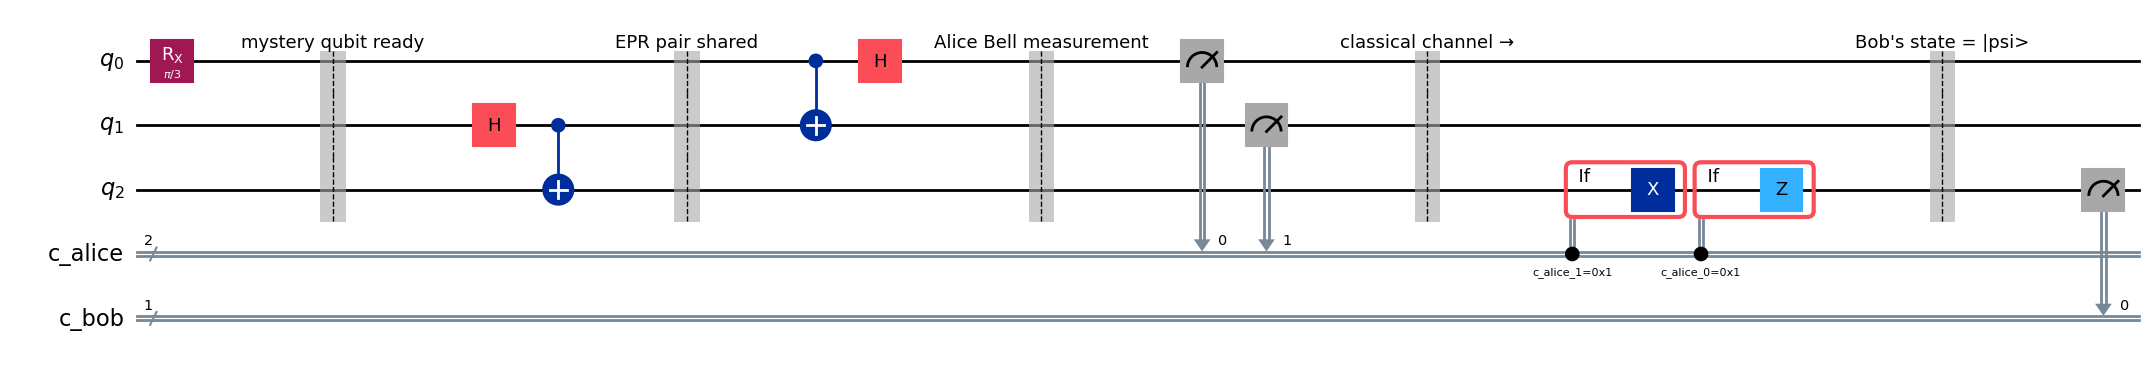

In [8]:
# ============================================================
# Circuit construction
# ============================================================
#
# Qubit layout:
#   q[0] = Alice's MYSTERY qubit  (the state to teleport)
#   q[1] = Alice's EPR qubit      (her half of the Bell pair)
#   q[2] = Bob's EPR qubit        (his half of the Bell pair)
#
# Classical register layout:
#   c_alice[0] = measurement result of q[0]  → triggers Z correction
#   c_alice[1] = measurement result of q[1]  → triggers X correction
#   c_bob[0]   = Bob's final measurement     → for histogram analysis
#
# Protocol derivation:
# Start:  |psi>_0 |Phi+>_12 = (a|0>+b|1>)(|00>+|11>)/sqrt(2)
# After CNOT(q0->q1) and H(q0), the 3-qubit state is:
#
#   (1/2)[ |00>(a|0>+b|1>) + |01>(a|1>+b|0>)   <- Bob's state per Alice outcome
#         + |10>(a|0>-b|1>) + |11>(-b|0>+a|1>) ]
#
# Bob's correction per Alice's (c_alice[0], c_alice[1]):
#   (0,0) -> I   (state already correct)
#   (0,1) -> X   (c_alice[1]=1 means q[1] was 1)
#   (1,0) -> Z   (c_alice[0]=1 means q[0] was 1)
#   (1,1) -> ZX  (apply X first, then Z)
# ============================================================

qr      = QuantumRegister(3, "q")
c_alice = ClassicalRegister(2, "c_alice")   # Alice's 2 classical bits
c_bob   = ClassicalRegister(1, "c_bob")     # Bob's measurement

qc = QuantumCircuit(qr, c_alice, c_bob, name="QuantumTeleportation")

# ── Step 1: Alice prepares her mystery qubit ─────────────────────
# Apply Rx(THETA) to q[0]. This is the state to be teleported.
# In a real scenario this state would be "unknown" to all parties.
qc.rx(THETA, qr[0])
qc.barrier(label="mystery qubit ready")

# ── Step 2: Create Bell pair between q[1] and q[2] ───────────────
# |Phi+> = (|00> + |11>) / sqrt(2)
# Alice holds q[1], Bob holds q[2].
# This pair is distributed before the protocol begins.
qc.h(qr[1])                     # H: |0> → (|0>+|1>)/sqrt(2) on q[1]
qc.cx(qr[1], qr[2])             # CNOT entangles q[1] and q[2]
qc.barrier(label="EPR pair shared")

# ── Step 3: Alice performs her Bell-basis measurement ─────────────
# Alice entangles her mystery qubit with her EPR qubit:
#   CNOT with q[0] as control, q[1] as target
#   H on q[0]
# This rotates into the Bell basis — equivalent to asking
# "which Bell state is |psi> ⊗ |Phi+> in?"
qc.cx(qr[0], qr[1])             # Entangle mystery qubit with EPR qubit
qc.h(qr[0])                     # Rotate mystery qubit to computational basis
qc.barrier(label="Alice Bell measurement")

# ── Step 4: Alice measures her two qubits ────────────────────────
# Results land in c_alice[0] (from q[0]) and c_alice[1] (from q[1]).
# These 2 classical bits are communicated to Bob over a classical channel.
qc.measure(qr[0], c_alice[0])
qc.measure(qr[1], c_alice[1])
qc.barrier(label="classical channel →")

# ── Step 5: Bob applies conditional Pauli corrections ─────────────
# Based on Alice's 2 classical bits, Bob recovers |psi> exactly.
# Modern Qiskit 2.x syntax: if_test context manager.
#
# Rule: if_test((classical_bit, expected_value))
#
# X correction: triggered by c_alice[1] (q[1]'s measurement result)
with qc.if_test((c_alice[1], 1)):
    qc.x(qr[2])

# Z correction: triggered by c_alice[0] (q[0]'s measurement result)
with qc.if_test((c_alice[0], 1)):
    qc.z(qr[2])

qc.barrier(label="Bob's state = |psi>")

# ── Step 6: Bob measures his qubit ───────────────────────────────
qc.measure(qr[2], c_bob[0])

print("Circuit construction complete.")
print(f"Depth       : {qc.depth()}")
print(f"Operations  : {dict(qc.count_ops())}")
print(f"\nText circuit view:\n")
qc.draw(output="mpl", filename="circuit.jpg", fold=-1)


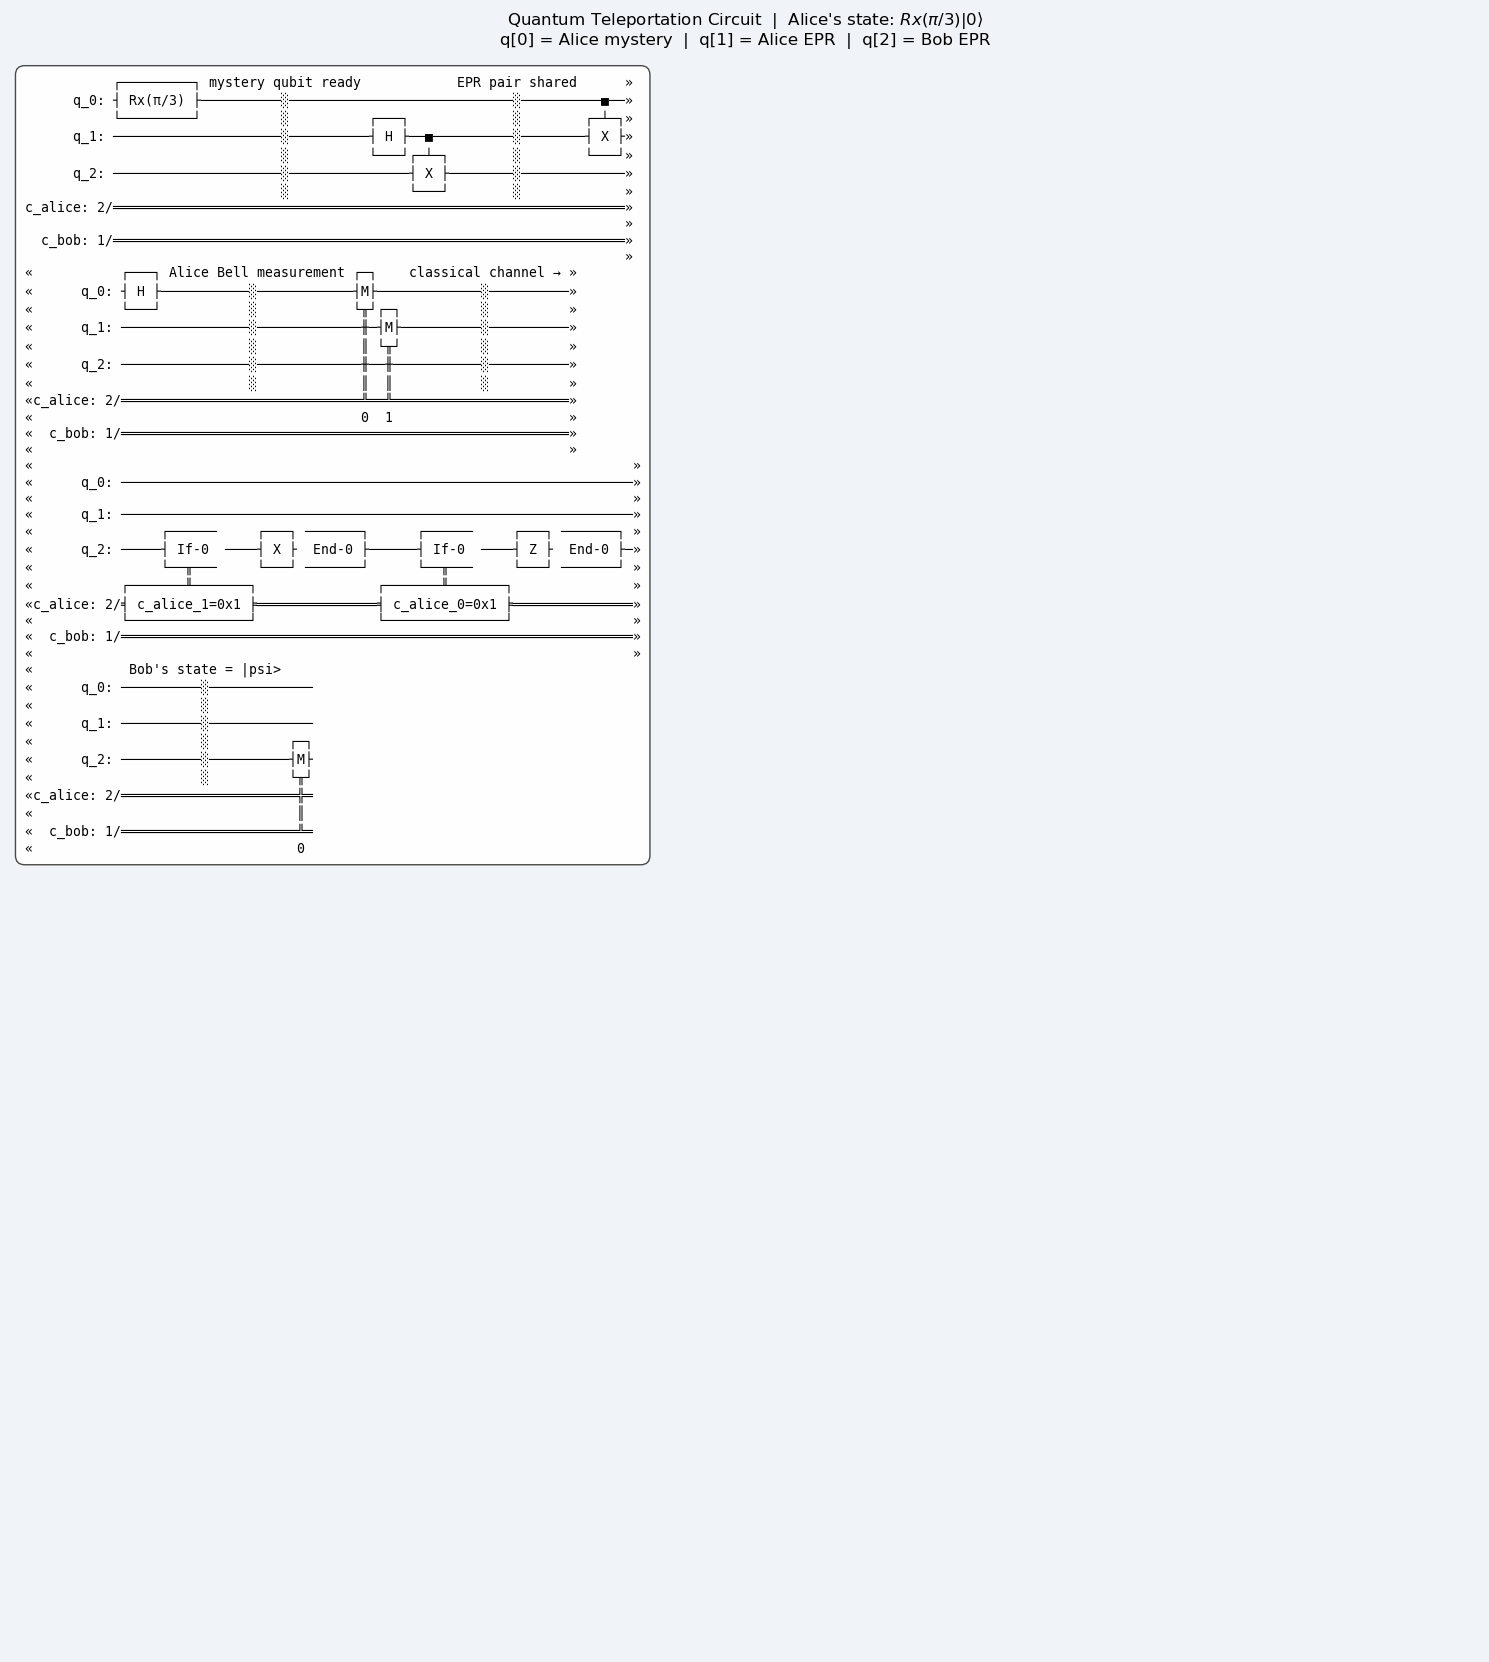

In [7]:
# ============================================================
# Render the text circuit as a clean Matplotlib figure
# ============================================================
# We use Qiskit's text drawer and embed it in matplotlib.
# This is the reliable approach that avoids the pylatexenc
# dependency required by output='mpl'. [same fix as before]

text_diagram = str(qc.draw(output="text"))

line_count = text_diagram.count("\n")
fig_h = max(4.5, line_count * 0.38)

fig_circ, ax_circ = plt.subplots(figsize=(15, fig_h))
fig_circ.patch.set_facecolor("#f0f4f8")
ax_circ.set_facecolor("#f0f4f8")
ax_circ.axis("off")

ax_circ.text(
    0.01, 0.99, text_diagram,
    transform=ax_circ.transAxes,
    va="top", ha="left",
    family="monospace",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.7",
              facecolor="white",
              edgecolor="#444444",
              alpha=0.97)
)

ax_circ.set_title(
    rf"Quantum Teleportation Circuit  |  Alice's state: $Rx(\pi/3)|0\rangle$"
    "\n"
    r"q[0] = Alice mystery  |  q[1] = Alice EPR  |  q[2] = Bob EPR",
    fontsize=12, pad=10
)

plt.tight_layout()
plt.show()


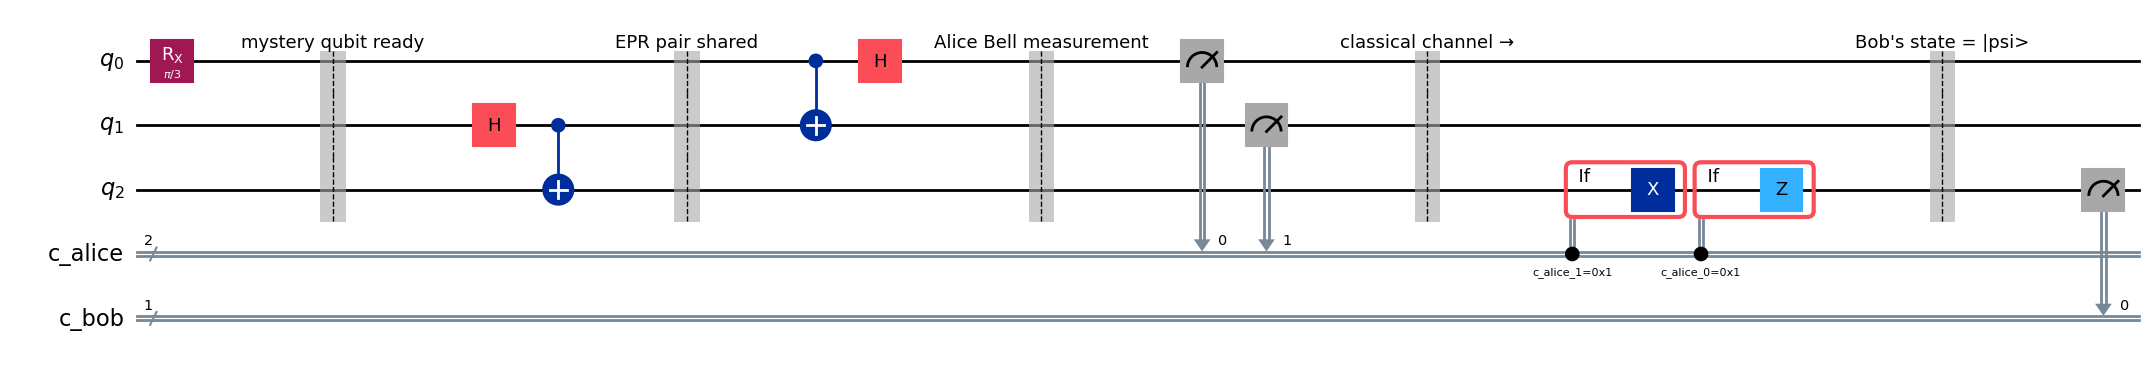

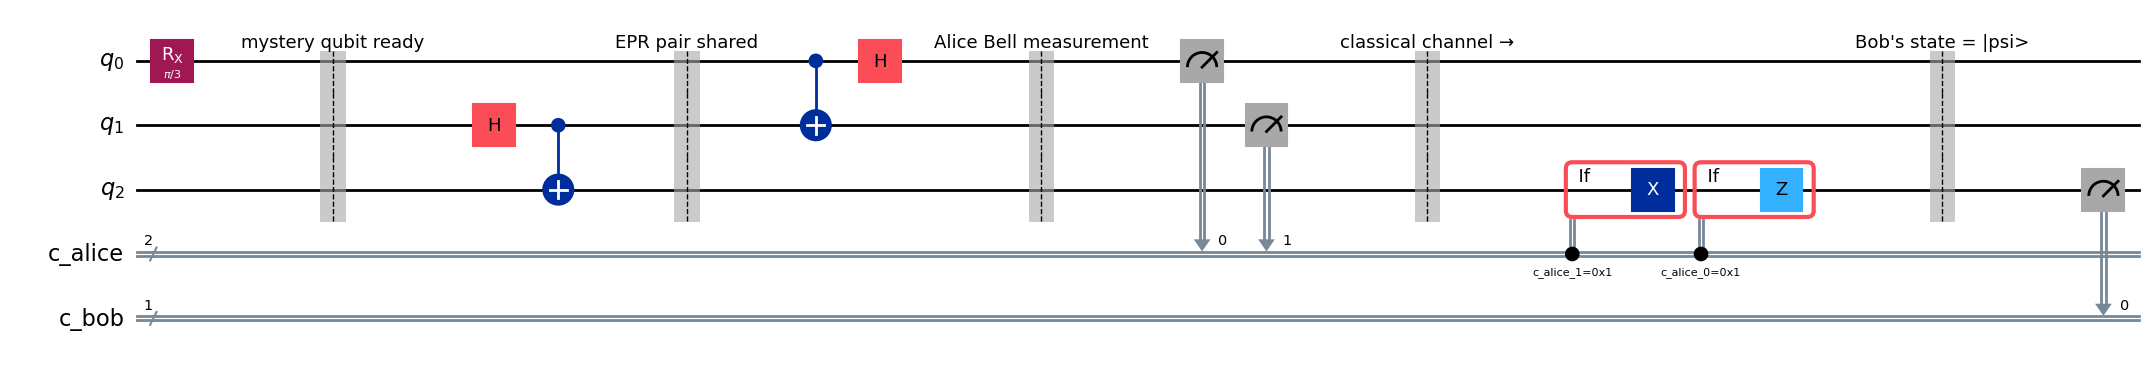

In [9]:
qc.draw(output="mpl", filename="circuit.jpg", fold=-1)